In [27]:
from confidence_correctness_matrix import *
from ucimlrepo import fetch_ucirepo
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# **Without Cross-Validation**

**Initialization and Training**

In [28]:
# Loads the iris dataset
iris  = fetch_ucirepo(id=53)
X, y = iris.data.features, iris.data.targets.squeeze()

classes = np.unique(y)
print(f"Classes: {classes}\n")

np.set_printoptions(suppress=True, formatter={'float': '{: 0.3f}'.format})

# Training and predict
model = GaussianNB().fit(X, y)
y_score = model.predict_proba(X)

Classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']



**Probabilistic Confusion Matrix**

In [29]:
# Calculates the probabilistic confusion matrix and the probabilistic metrics
prob_conf_matrix = prob_confusion_matrix(y, y_score, labels=classes)
prob_acc = prob_accuracy_score(y, y_score)
prob_b_acc = prob_balanced_accuracy_score(y, y_score)
prob_prec = prob_precision_score(y, y_score, average="micro")
prob_recall = prob_recall_score(y, y_score, average="macro")
prob_f1 = prob_f1_score(y, y_score, average="weighted")
prob_cohen_kappa = prob_cohen_kappa_score(y, y_score)
prob_m_corrcoef = prob_matthews_corrcoef(y, y_score)

print(f"Probabilistic confusion matrix:\n {prob_conf_matrix}\n")
print(f"Acc* = {prob_acc:.3f}, B_acc* = {prob_b_acc:.3f}, Prec* = {prob_prec:.3f}, MCC* = {prob_m_corrcoef:.3f}, Recall* = {prob_recall:.3f}, F1* = {prob_f1:.3f}, Cohen Kappa* = {prob_cohen_kappa:.3f}\n")

Probabilistic confusion matrix:
 [[ 50.000  0.000  0.000]
 [ 0.000  46.060  3.940]
 [ 0.000  3.930  46.070]]

Acc* = 0.948, B_acc* = 0.948, Prec* = 0.948, MCC* = 1.000, Recall* = 0.948, F1* = 0.948, Cohen Kappa* = 0.927



**High-Confidence and Low-Confidence Matrices**

In [30]:
# Calculates the high-confidence and low-confidence matrices and their lambda values
H, L = confidence_matrices(y, y_score)
lambda_H, lambda_L = confidence_weights(y, y_score)

print(f"High-Confidence matrix:\n {H}")
print(f"lambda_H = {lambda_H:.3f}\n")
print(f"Low-Confidence matrix:\n {L}")
print(f"lambda_L = {lambda_L:.3f}\n")

High-Confidence matrix:
 [[ 50.000  0.000  0.000]
 [ 0.000  45.374  2.314]
 [ 0.000  2.644  45.715]]
lambda_H = 0.974

Low-Confidence matrix:
 [[ 0.000  0.000  0.000]
 [ 0.000  0.686  1.626]
 [ 0.000  1.285  0.356]]
lambda_L = 0.026



**Class-independent Confidence-Correctness Matrix**

In [31]:
# Calculates the class-independent Confidence-Correctnes matrix
ci_confCorrM = confidence_correctness_matrix(y, y_score, class_specific=False)
print("Class-independent Confidence-Correctnes matrix values:")
for key, value in ci_confCorrM.items():
    print(f"{key}: {value:.3f}")

Class-independent Confidence-Correctnes matrix values:
Reliability: 0.941
Overconfidence: 0.033
Underconfidence: 0.019
Ambiguity: 0.007


**Class-specific Confident-Correctness Matrix**

In [32]:
# Loads wine-quality the dataset
wine_quality  = fetch_ucirepo(id=186)
X, y = wine_quality.data.features, wine_quality.data.targets.squeeze()

classes = np.unique(y)
print(f"Classes: {classes}\n")

np.set_printoptions(suppress=True, formatter={'float': '{: 0.3f}'.format})

# Training and predict
model = GaussianNB().fit(X, y)
y_score = model.predict_proba(X)

# Calculates the class-specific Confidence-Correctnes matrix
cd_confCorrM = confidence_correctness_matrix(y, y_score, class_specific=True)
print("\nClass-dependent Confidence-Correctnes matrix values:")
for key, value in cd_confCorrM.items():
    print(f"\nClass {key}")
    for key2, value2 in value.items():
        print(f"{key2}: {value2:.3f}")

Classes: [3 4 5 6 7 8 9]


Class-dependent Confidence-Correctnes matrix values:

Class 3
Reliability: 0.188
Overconfidence: 0.482
Ambiguity: 0.057
Underconfidence: 0.274

Class 4
Reliability: 0.088
Overconfidence: 0.487
Ambiguity: 0.061
Underconfidence: 0.363

Class 5
Reliability: 0.350
Overconfidence: 0.235
Ambiguity: 0.100
Underconfidence: 0.315

Class 6
Reliability: 0.216
Overconfidence: 0.332
Ambiguity: 0.155
Underconfidence: 0.297

Class 7
Reliability: 0.299
Overconfidence: 0.240
Ambiguity: 0.083
Underconfidence: 0.377

Class 8
Reliability: 0.023
Overconfidence: 0.520
Ambiguity: 0.147
Underconfidence: 0.310

Class 9
Reliability: 0.217
Overconfidence: 0.307
Ambiguity: 0.060
Underconfidence: 0.415


**Class-specific Confident-Correctness Matrix Bar Chart**

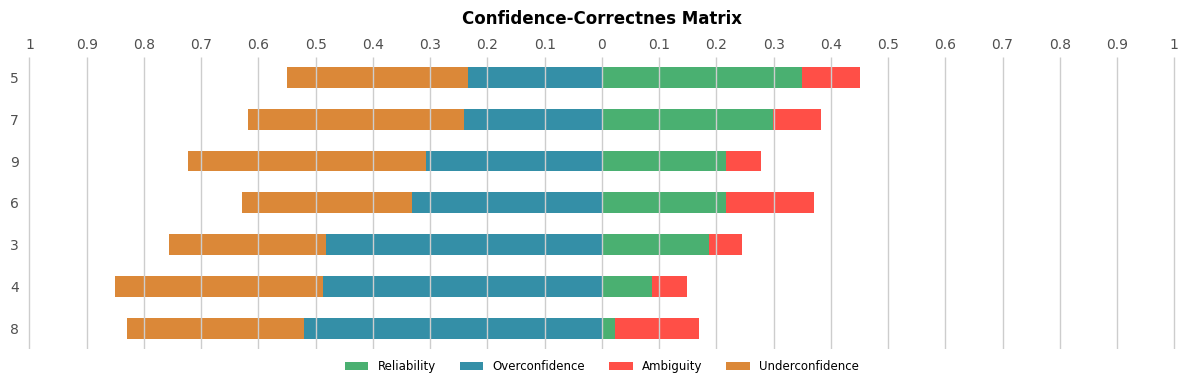

In [33]:
# Plots the class-dependent Confidence-Correctnes matrix
plot_confidence(y, y_score)

# **With Cross-Validation**

**Initialization and Training**

In [34]:
# Parameters
K = 10
class_col = "type"
file = "Leukemia_GSE28497.csv"

# Reads the file
dataset = pd.read_csv(file)

# Prepares the dataset
dataset = dataset.drop(columns="samples")

X = dataset.drop(columns=class_col)
y = dataset[class_col]

classes = np.unique(y)
print(f"Classes: {classes}\n")

np.set_printoptions(suppress=True, formatter={'float': '{: 0.3f}'.format})

# Initializes the variables for the results
aggregated_y = np.array([])
aggregated_y_score = np.empty((0, len(np.unique(y))))

# Initializes the validation model
kf = StratifiedKFold(K, random_state=0, shuffle=True)
for train, test in kf.split(X, y):
    # Splits in train and test
    X_train, y_train = X.iloc[train], y.iloc[train]
    X_test, y_test = X.iloc[test], y.iloc[test]

    # Training and predict
    model = RandomForestClassifier(random_state=0).fit(X_train, y_train)
    y_score = model.predict_proba(X_test)

    # Aggregates y_test and the results
    aggregated_y = np.concatenate((aggregated_y, y_test)).flatten()
    aggregated_y_score = np.concatenate((aggregated_y_score, y_score))

Classes: ['B-CELL_ALL' 'B-CELL_ALL_ETV6-RUNX1' 'B-CELL_ALL_HYPERDIP'
 'B-CELL_ALL_HYPO' 'B-CELL_ALL_MLL' 'B-CELL_ALL_T-ALL'
 'B-CELL_ALL_TCF3-PBX1']



**Probabilistic Confusion Matrix**

In [35]:
# Calculates the probabilistic confusion matrix and the probabilistic metrics
prob_conf_matrix = prob_confusion_matrix(aggregated_y, aggregated_y_score, labels=classes)
prob_acc = prob_accuracy_score(aggregated_y, aggregated_y_score)
prob_b_acc = prob_balanced_accuracy_score(aggregated_y, aggregated_y_score)
prob_prec = prob_precision_score(aggregated_y, aggregated_y_score, average="micro")
prob_recall = prob_recall_score(aggregated_y, aggregated_y_score, average="macro")
prob_f1 = prob_f1_score(aggregated_y, aggregated_y_score, average="weighted")
prob_cohen_kappa = prob_cohen_kappa_score(aggregated_y, aggregated_y_score)
prob_m_corrcoef = prob_matthews_corrcoef(aggregated_y, aggregated_y_score)

print(f"Probabilistic confusion matrix:\n {prob_conf_matrix}\n")
print(f"Acc* = {prob_acc:.3f}, B_acc* = {prob_b_acc:.3f}, Prec* = {prob_prec:.3f}, MCC* = {prob_m_corrcoef:.3f}, Recall* = {prob_recall:.3f}, F1* = {prob_f1:.3f}, Cohen Kappa* = {prob_cohen_kappa:.3f}\n")

Probabilistic confusion matrix:
 [[ 36.080  8.720  10.890  7.970  4.110  3.190  3.040]
 [ 8.580  36.150  2.770  2.550  0.780  1.070  1.100]
 [ 10.730  2.620  30.440  3.620  1.520  1.000  1.070]
 [ 7.820  1.810  3.170  2.490  1.090  0.730  0.890]
 [ 4.280  0.840  1.670  1.830  5.990  1.320  1.070]
 [ 3.440  1.050  1.220  0.940  1.270  37.310  0.770]
 [ 3.520  1.160  0.910  1.160  1.080  0.660  13.510]]

Acc* = 0.576, B_acc* = 0.526, Prec* = 0.576, MCC* = 0.302, Recall* = 0.526, F1* = 0.579, Cohen Kappa* = 0.664



**High-Confidence and Low-Confidence Matrices**

In [36]:
# Calculates the high-confidence and low-confidence matrices and their lambda values
H, L = confidence_matrices(aggregated_y, aggregated_y_score)
lambda_H, lambda_L = confidence_weights(aggregated_y, aggregated_y_score)

print(f"High-Confidence matrix:\n {H}")
print(f"lambda_H = {lambda_H:.3f}\n")
print(f"Low-Confidence matrix:\n {L}")
print(f"lambda_L = {lambda_L:.3f}\n")

High-Confidence matrix:
 [[ 31.800  3.390  2.870  0.000  0.000  0.340  0.000]
 [ 0.230  35.940  0.000  0.000  0.000  0.000  0.000]
 [ 1.530  0.000  29.560  0.000  0.000  0.000  0.000]
 [ 6.690  0.860  0.900  0.000  0.000  0.000  0.000]
 [ 0.930  0.000  0.000  0.000  5.210  0.000  0.000]
 [ 0.000  0.000  0.000  0.000  0.000  37.310  0.000]
 [ 0.300  0.000  0.000  0.000  0.000  0.000  13.380]]
lambda_H = 0.609

Low-Confidence matrix:
 [[ 4.280  5.330  8.020  7.970  4.110  2.850  3.040]
 [ 8.350  0.210  2.770  2.550  0.780  1.070  1.100]
 [ 9.200  2.620  0.880  3.620  1.520  1.000  1.070]
 [ 1.130  0.950  2.270  2.490  1.090  0.730  0.890]
 [ 3.350  0.840  1.670  1.830  0.780  1.320  1.070]
 [ 3.440  1.050  1.220  0.940  1.270  0.000  0.770]
 [ 3.220  1.160  0.910  1.160  1.080  0.660  0.130]]
lambda_L = 0.391



**Class-independent Confidence-Correctness Matrix**

In [37]:
# Calculates the class-independent Confidence-Correctnes matrix
ci_confCorrM = confidence_correctness_matrix(aggregated_y, aggregated_y_score, class_specific=False)
print("Class-independent Confidence-Correctnes matrix values:")
for key, value in ci_confCorrM.items():
    print(f"{key}: {value:.3f}")

Class-independent Confidence-Correctnes matrix values:
Reliability: 0.545
Overconfidence: 0.064
Underconfidence: 0.359
Ambiguity: 0.031


**Class-specific Confident-Correctness Matrix**

In [38]:
# Calculates the class-specific Confidence-Correctnes matrix
cd_confCorrM = confidence_correctness_matrix(aggregated_y, aggregated_y_score, class_specific=True)
print("\nClass-dependent Confidence-Correctnes matrix values:")
for key, value in cd_confCorrM.items():
    print(f"\nClass {key}")
    for key2, value2 in value.items():
        print(f"{key2}: {value2:.3f}")


Class-dependent Confidence-Correctnes matrix values:

Class B-CELL_ALL
Reliability: 0.430
Overconfidence: 0.089
Ambiguity: 0.058
Underconfidence: 0.423

Class B-CELL_ALL_ETV6-RUNX1
Reliability: 0.678
Overconfidence: 0.004
Ambiguity: 0.004
Underconfidence: 0.314

Class B-CELL_ALL_HYPERDIP
Reliability: 0.580
Overconfidence: 0.030
Ambiguity: 0.017
Underconfidence: 0.373

Class B-CELL_ALL_HYPO
Reliability: 0.000
Overconfidence: 0.469
Ambiguity: 0.138
Underconfidence: 0.392

Class B-CELL_ALL_MLL
Reliability: 0.306
Overconfidence: 0.055
Ambiguity: 0.046
Underconfidence: 0.593

Class B-CELL_ALL_T-ALL
Reliability: 0.811
Overconfidence: 0.000
Ambiguity: 0.000
Underconfidence: 0.189

Class B-CELL_ALL_TCF3-PBX1
Reliability: 0.608
Overconfidence: 0.014
Ambiguity: 0.006
Underconfidence: 0.372


**Class-specific Confident-Correctness Matrix Bar Chart**

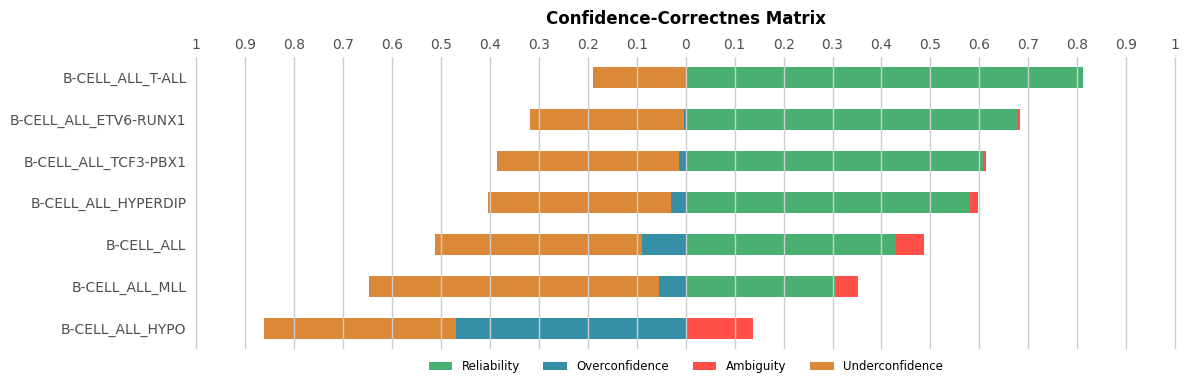

In [39]:
# Plots the class-specific Confidence-Correctnes matrix
plot_confidence(aggregated_y, aggregated_y_score)